# mnist_rl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/'Colab Notebooks'

/content/drive/MyDrive/Colab Notebooks


In [ ]:
!pip -q install torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# Data
# ----------------------------
tf = transforms.Compose([
    transforms.ToTensor(),  # [1,28,28] in [0,1]
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tf)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=tf)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------
# Policy network π(a|x)
# outputs logits for 10 actions
# ----------------------------
class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)  # logits

policy = PolicyNet().to(device)

# Optional: baseline network to reduce variance (value function V(x) ≈ E[r|x])
class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # [B]

baseline = BaselineNet().to(device)

opt_pi = torch.optim.Adam(policy.parameters(), lr=2e-4)
opt_v  = torch.optim.Adam(baseline.parameters(), lr=2e-4)

# ----------------------------
# Evaluate (greedy)
# ----------------------------
@torch.no_grad()
def eval_acc():
    policy.eval()
    correct, total = 0, 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = policy(x)
        pred = logits.argmax(dim=-1)
        correct += (pred == y).sum().item()
        total += y.numel()
    policy.train()
    return correct / total

# ----------------------------
# REINFORCE training (contextual bandit)
# ----------------------------
def train_epoch(epoch: int, log_every=200):
    policy.train()
    baseline.train()
    running_reward = 0.0
    running_acc = 0.0

    for step, (x, y) in enumerate(train_loader, start=1):
        x = x.to(device)
        y = y.to(device)

        logits = policy(x)
        dist = Categorical(logits=logits)
        a = dist.sample()                 # actions [B]
        logp = dist.log_prob(a)           # log π(a|x)

        # Bandit reward
        r = (a == y).float()              # [B] reward 0/1
        running_reward += r.mean().item()
        running_acc += (a == y).float().mean().item()

        # Baseline (variance reduction)
        v = baseline(x)                   # [B]
        adv = (r - v).detach()            # treat baseline as constant for policy update

        # Policy gradient loss: maximize E[ r * logπ ] -> minimize negative
        loss_pi = -(adv * logp).mean()

        # Baseline regression to reward
        loss_v = F.mse_loss(v, r)

        opt_pi.zero_grad(set_to_none=True)
        opt_v.zero_grad(set_to_none=True)
        (loss_pi + loss_v).backward()
        opt_pi.step()
        opt_v.step()

        if step % log_every == 0:
            avg_r = running_reward / log_every
            avg_a = running_acc / log_every
            running_reward = 0.0
            running_acc = 0.0
            print(f"epoch={epoch} step={step}  train_reward={avg_r:.3f}  sample_acc={avg_a:.3f}")

# ----------------------------
# Run
# ----------------------------
print("Initial test acc (greedy):", eval_acc())

for epoch in range(1, 6):
    train_epoch(epoch, log_every=200)
    print("Test acc (greedy):", eval_acc())

Initial test acc (greedy): 0.0837
epoch=1 step=200  train_reward=0.407  sample_acc=0.407
Test acc (greedy): 0.7945
epoch=2 step=200  train_reward=0.752  sample_acc=0.752
Test acc (greedy): 0.8907
epoch=3 step=200  train_reward=0.841  sample_acc=0.841
Test acc (greedy): 0.9038
epoch=4 step=200  train_reward=0.869  sample_acc=0.869
Test acc (greedy): 0.9119
epoch=5 step=200  train_reward=0.881  sample_acc=0.881
Test acc (greedy): 0.9162


In [ ]:

import math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

class GlimpseMNISTVecEnv:
    """
    Vectorized MDP:
      - At each step, pick a patch index to reveal.
      - On final step, also predict label (digit).
    """
    def __init__(self, images, labels, batch_size=256, patch=7, T=4, device="cuda"):
        """
        images: torch [N,1,28,28] in [0,1]
        labels: torch [N] int64
        patch: patch size (e.g. 7 -> 4x4 grid)
        T: number of glimpse steps. Reward only at final step.
        """
        self.images = images
        self.labels = labels
        self.N = images.size(0)
        self.B = batch_size
        self.patch = patch
        self.T = T
        self.device = device

        assert 28 % patch == 0
        self.grid = 28 // patch
        self.n_patches = self.grid * self.grid

        # state
        self.idx = None
        self.t = None
        self.full = None
        self.y = None
        self.mask = None
        self.obs = None

    # def reset(self):
    #     idx = torch.randint(0, self.N, (self.B,), device=self.device)
    #     self.idx = idx
    #     self.full = self.images[idx].to(self.device)     # [B,1,28,28]
    #     self.y = self.labels[idx].to(self.device)        # [B]
    #     self.t = torch.zeros(self.B, dtype=torch.long, device=self.device)

    #     # mask of revealed pixels
    #     self.mask = torch.zeros((self.B, 1, 28, 28), device=self.device)
    #     self.obs = torch.zeros((self.B, 1, 28, 28), device=self.device)
    #     return self.obs.clone()
    def reset(self):
    # IMPORTANT: idx must be on CPU because self.images/self.labels are on CPU
    # fix changes device to be CPU whereas error one had it autodetect the GPU
    # with device=device
      idx = torch.randint(0, self.N, (self.B,), device="cpu")
      self.idx = idx

    # index on CPU, then move to GPU
      self.full = self.images[idx].to(self.device)     # [B,1,28,28]
      self.y = self.labels[idx].to(self.device)        # [B]
      self.t = torch.zeros(self.B, dtype=torch.long, device=self.device)

      self.mask = torch.zeros((self.B, 1, 28, 28), device=self.device)
      self.obs  = torch.zeros((self.B, 1, 28, 28), device=self.device)
      return self.obs.clone()

    def _reveal_patch(self, patch_idx):
        # patch_idx: [B] in [0, n_patches)
        g = self.grid
        p = self.patch
        r = patch_idx // g
        c = patch_idx % g
        r0 = r * p
        c0 = c * p
        # Reveal patch per batch element
        for b in range(self.B):
            rr0 = int(r0[b].item())
            cc0 = int(c0[b].item())
            self.mask[b, :, rr0:rr0+p, cc0:cc0+p] = 1.0

        self.obs = self.full * self.mask
        return self.obs

    def step(self, patch_action, pred_action=None):
        """
        patch_action: [B] choose patch to reveal now
        pred_action:  [B] digit prediction (required only on final step)
        returns: obs, reward, done
        """
        self._reveal_patch(patch_action)
        self.t += 1
        done = (self.t >= self.T)

        reward = torch.zeros(self.B, device=self.device)
        if done.any():
            if pred_action is None:
                raise ValueError("pred_action required at final step.")
            # reward only at end
            reward = (pred_action == self.y).float()

        return self.obs.clone(), reward, done
class PatchAndDigitPolicy(nn.Module):
    def __init__(self, n_patches, T, hidden=256):
        super().__init__()
        self.n_patches = n_patches
        self.T = T

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7
            nn.Flatten(),
        )
        self.feat_dim = 64 * 7 * 7
        self.t_embed = nn.Embedding(T+1, 32)

        self.trunk = nn.Sequential(
            nn.Linear(self.feat_dim + 32, hidden),
            nn.Tanh(),
        )

        self.patch_head = nn.Linear(hidden, n_patches)
        self.digit_head = nn.Linear(hidden, 10)
        self.value_head = nn.Linear(hidden, 1)

    def forward(self, obs, t):
        # obs: [B,1,28,28], t: [B] in [0..T]
        f = self.cnn(obs)
        te = self.t_embed(t)
        x = torch.cat([f, te], dim=-1)
        h = self.trunk(x)
        patch_logits = self.patch_head(h)
        digit_logits = self.digit_head(h)
        value = self.value_head(h).squeeze(-1)
        return patch_logits, digit_logits, value

@torch.no_grad()
def rollout(env, policy, gamma=0.99, lam=0.95):
    """
    Collect one rollout of length T in the vectorized env.
    Returns dict of tensors with shapes:
      obs: [T,B,1,28,28]
      t: [T,B]
      patch_a: [T,B]
      digit_a: [T,B] (only meaningful at final step)
      logp: [T,B] (log prob of joint action; we define it as patch + (if final) digit)
      r: [T,B]
      v: [T,B]
      adv/ret: [T,B]
    """
    B = env.B
    T = env.T
    device = env.device

    obs = env.reset()
    t = torch.zeros(B, dtype=torch.long, device=device)

    obses, ts, patch_as, digit_as, logps, rs, vs, dones = [], [], [], [], [], [], [], []

    for step in range(T):
        patch_logits, digit_logits, v = policy(obs, t)
        patch_dist = Categorical(logits=patch_logits)
        patch_a = patch_dist.sample()
        patch_logp = patch_dist.log_prob(patch_a)

        # Only pick digit on final step (still sample for bookkeeping)
        digit_dist = Categorical(logits=digit_logits)
        digit_a = digit_dist.sample()
        digit_logp = digit_dist.log_prob(digit_a)

        is_final = (step == T - 1)
        joint_logp = patch_logp + (digit_logp if is_final else 0.0)

        next_obs, r, done = env.step(patch_a, pred_action=digit_a if is_final else None)

        obses.append(obs)
        ts.append(t.clone())
        patch_as.append(patch_a)
        digit_as.append(digit_a)
        logps.append(joint_logp)
        rs.append(r)
        vs.append(v)
        dones.append(done)

        obs = next_obs
        t = t + 1

    # GAE
    v = torch.stack(vs, dim=0)     # [T,B]
    r = torch.stack(rs, dim=0)     # [T,B]
    d = torch.stack(dones, dim=0)  # [T,B] bool (only last true)

    # bootstrap value after end: 0 because episode ends at T
    next_v = torch.zeros(B, device=device)

    adv = torch.zeros_like(r)
    last_gae = torch.zeros(B, device=device)

    for i in reversed(range(T)):
        not_done = 1.0 - d[i].float()  # mostly 1 except final
        v_next = next_v if i == T-1 else v[i+1]
        delta = r[i] + gamma * v_next * not_done - v[i]
        last_gae = delta + gamma * lam * not_done * last_gae
        adv[i] = last_gae

    ret = adv + v
    # normalize advantages across all steps/batch
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    out = {
        "obs": torch.stack(obses, dim=0),
        "t": torch.stack(ts, dim=0),
        "patch_a": torch.stack(patch_as, dim=0),
        "digit_a": torch.stack(digit_as, dim=0),
        "logp_old": torch.stack(logps, dim=0),
        "r": r,
        "v": v,
        "adv": adv,
        "ret": ret,
    }
    return out


def ppo_update(policy, opt, batch, clip_eps=0.2, vf_coef=0.5, ent_coef=0.01,
               epochs=4, minibatch=1024):
    device = batch["obs"].device
    T, B = batch["patch_a"].shape
    N = T * B

    obs = batch["obs"].reshape(N, 1, 28, 28)
    t = batch["t"].reshape(N)
    patch_a = batch["patch_a"].reshape(N)
    digit_a = batch["digit_a"].reshape(N)
    logp_old = batch["logp_old"].reshape(N)
    adv = batch["adv"].reshape(N)
    ret = batch["ret"].reshape(N)

    # mask: digit part only on final step positions
    # final step indices are those with t == T-1
    is_final = (t == (T - 1)).float()

    idx = torch.arange(N, device=device)

    for _ in range(epochs):
        perm = idx[torch.randperm(N)]
        for start in range(0, N, minibatch):
            mb = perm[start:start+minibatch]
            mb_obs = obs[mb]
            mb_t = t[mb]
            mb_patch_a = patch_a[mb]
            mb_digit_a = digit_a[mb]
            mb_logp_old = logp_old[mb]
            mb_adv = adv[mb]
            mb_ret = ret[mb]
            mb_is_final = is_final[mb]

            patch_logits, digit_logits, v = policy(mb_obs, mb_t)

            patch_dist = Categorical(logits=patch_logits)
            digit_dist = Categorical(logits=digit_logits)

            patch_logp = patch_dist.log_prob(mb_patch_a)
            digit_logp = digit_dist.log_prob(mb_digit_a)

            logp = patch_logp + mb_is_final * digit_logp
            ratio = torch.exp(logp - mb_logp_old)

            surr1 = ratio * mb_adv
            surr2 = torch.clamp(ratio, 1-clip_eps, 1+clip_eps) * mb_adv
            actor_loss = -torch.min(surr1, surr2).mean()

            critic_loss = F.mse_loss(v, mb_ret)
            entropy = (patch_dist.entropy().mean() + digit_dist.entropy().mean())

            loss = actor_loss + vf_coef * critic_loss - ent_coef * entropy

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(policy.parameters(), 0.5)
            opt.step()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Load MNIST tensors (fast for vectorized env)
tf = transforms.ToTensor()
train_ds = datasets.MNIST("./data", train=True, download=True, transform=tf)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tf)

# Materialize to tensors on CPU, move batches to GPU in env
train_images = torch.stack([train_ds[i][0] for i in range(len(train_ds))], dim=0)  # [60000,1,28,28]
train_labels = torch.tensor([train_ds[i][1] for i in range(len(train_ds))], dtype=torch.long)

test_images = torch.stack([test_ds[i][0] for i in range(len(test_ds))], dim=0)
test_labels = torch.tensor([test_ds[i][1] for i in range(len(test_ds))], dtype=torch.long)

# Hyperparams
B = 256
patch = 7     # 4x4 grid = 16 patch actions
T_steps = 4   # 4 glimpses then predict (predict happens on final step)
env = GlimpseMNISTVecEnv(train_images, train_labels, batch_size=B, patch=patch, T=T_steps, device=device)

policy = PatchAndDigitPolicy(n_patches=env.n_patches, T=T_steps).to(device)
opt = torch.optim.Adam(policy.parameters(), lr=3e-4)

@torch.no_grad()
def eval_greedy(n_batches=50):
    # Evaluate greedy digit prediction after T glimpses chosen greedily (max prob) or sampled?
    # We'll do: patch = argmax(pi_patch), digit = argmax(pi_digit) at final
    env_eval = GlimpseMNISTVecEnv(test_images, test_labels, batch_size=B, patch=patch, T=T_steps, device=device)
    obs = env_eval.reset()
    t = torch.zeros(B, dtype=torch.long, device=device)
    correct = 0
    total = 0
    for _ in range(n_batches):
        obs = env_eval.reset()
        t = torch.zeros(B, dtype=torch.long, device=device)
        for step in range(T_steps):
            patch_logits, digit_logits, _ = policy(obs, t)
            patch_a = patch_logits.argmax(dim=-1)
            digit_a = digit_logits.argmax(dim=-1)
            obs, r, done = env_eval.step(patch_a, pred_action=digit_a if step==T_steps-1 else None)
            t = t + 1
        # reward is 1 if correct
        correct += r.sum().item()
        total += r.numel()
    return correct / total

# Train
updates = 200  # ~ a few minutes on GPU; reduce if needed
for u in range(1, updates+1):
    batch = rollout(env, policy)
    ppo_update(policy, opt, batch, epochs=4, minibatch=1024)

    if u % 10 == 0:
        avg_final_reward = batch["r"][-1].mean().item()   # success rate in rollout
        acc = eval_greedy(n_batches=20)
        print(f"update={u:04d}  rollout_success={avg_final_reward:.3f}  test_greedy_acc={acc:.3f}")

device: cuda
update=0010  rollout_success=0.105  test_greedy_acc=0.129
update=0020  rollout_success=0.180  test_greedy_acc=0.219
update=0030  rollout_success=0.230  test_greedy_acc=0.305
update=0040  rollout_success=0.352  test_greedy_acc=0.434
update=0050  rollout_success=0.430  test_greedy_acc=0.516
update=0060  rollout_success=0.457  test_greedy_acc=0.561
update=0070  rollout_success=0.555  test_greedy_acc=0.596
update=0080  rollout_success=0.574  test_greedy_acc=0.610
update=0090  rollout_success=0.590  test_greedy_acc=0.642
update=0100  rollout_success=0.609  test_greedy_acc=0.656
update=0110  rollout_success=0.617  test_greedy_acc=0.684
update=0120  rollout_success=0.688  test_greedy_acc=0.702
update=0130  rollout_success=0.707  test_greedy_acc=0.718
update=0140  rollout_success=0.684  test_greedy_acc=0.727
update=0150  rollout_success=0.719  test_greedy_acc=0.738
update=0160  rollout_success=0.734  test_greedy_acc=0.771
update=0170  rollout_success=0.773  test_greedy_acc=0.775
u

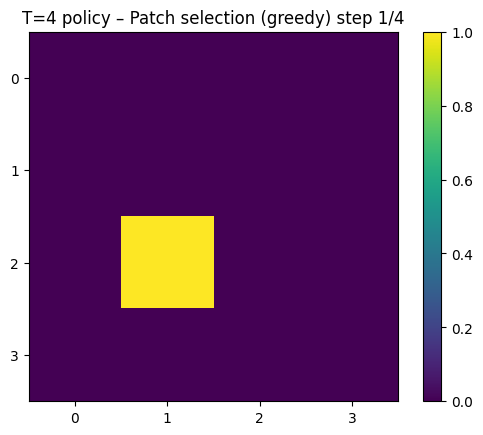

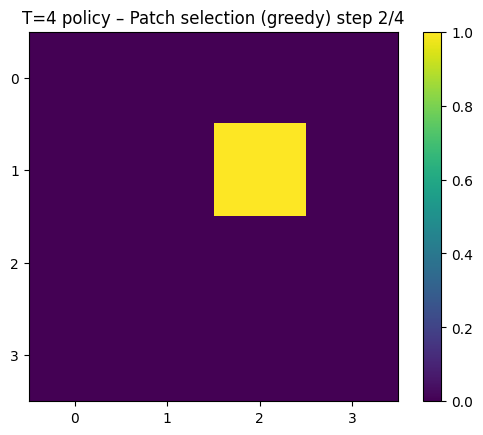

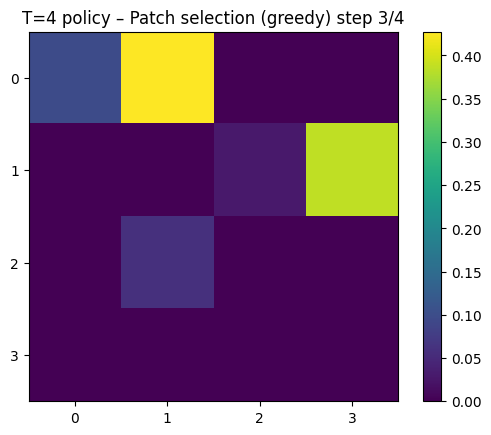

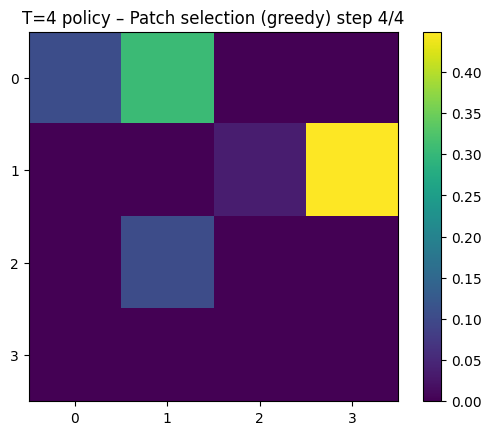

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def collect_patch_heatmaps(policy, T_steps, patch=7, batch_size=512, n_batches=30, device="cuda"):
    env_eval = GlimpseMNISTVecEnv(test_images, test_labels, batch_size=batch_size, patch=patch, T=T_steps, device=device)
    g = env_eval.grid  # grid x grid patches
    counts = torch.zeros((T_steps, g, g), dtype=torch.float32)

    for _ in range(n_batches):
        obs = env_eval.reset()
        t = torch.zeros(batch_size, dtype=torch.long, device=device)

        for step in range(T_steps):
            patch_logits, digit_logits, _ = policy(obs, t)
            patch_a = patch_logits.argmax(dim=-1)  # [B]
            r = (patch_a // g).tolist()
            c = (patch_a % g).tolist()
            for rr, cc in zip(r, c):
                counts[step, rr, cc] += 1.0

            # advance env
            digit_a = digit_logits.argmax(dim=-1)
            obs, _, _ = env_eval.step(patch_a, pred_action=digit_a if step == T_steps-1 else None)
            t = t + 1

    # normalize per timestep -> probabilities
    probs = counts / counts.sum(dim=(1,2), keepdim=True).clamp_min(1e-9)
    return probs.cpu().numpy(), g

def plot_heatmaps(probs, g, title_prefix):
    T_steps = probs.shape[0]
    for step in range(T_steps):
        plt.figure()
        plt.imshow(probs[step], aspect="equal")
        plt.title(f"{title_prefix} – Patch selection (greedy) step {step+1}/{T_steps}")
        plt.xticks(range(g)); plt.yticks(range(g))
        plt.colorbar()
        plt.show()
policy.eval()
probs4, g = collect_patch_heatmaps(policy, T_steps=4, patch=7, device=device)
plot_heatmaps(probs4, g, "T=4 policy")

In [ ]:
@torch.no_grad()
def eval_greedy(policy, T_steps, patch=7, batch_size=256, n_batches=30, device="cuda"):
    env_eval = GlimpseMNISTVecEnv(test_images, test_labels, batch_size=batch_size, patch=patch, T=T_steps, device=device)
    correct = 0
    total = 0
    for _ in range(n_batches):
        obs = env_eval.reset()
        t = torch.zeros(batch_size, dtype=torch.long, device=device)
        r = None
        for step in range(T_steps):
            patch_logits, digit_logits, _ = policy(obs, t)
            patch_a = patch_logits.argmax(dim=-1)
            digit_a = digit_logits.argmax(dim=-1)
            obs, r, done = env_eval.step(patch_a, pred_action=digit_a if step==T_steps-1 else None)
            t = t + 1
        correct += r.sum().item()
        total += r.numel()
    return correct / total

In [ ]:
def train_policy(T_steps, patch=7, B=256, updates=200, lr=3e-4, device="cuda", seed=0):
    import random, numpy as np
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

    env = GlimpseMNISTVecEnv(train_images, train_labels, batch_size=B, patch=patch, T=T_steps, device=device)
    policy = PatchAndDigitPolicy(n_patches=env.n_patches, T=T_steps).to(device)
    opt = torch.optim.Adam(policy.parameters(), lr=lr)

    xs, test_acc = [], []
    for u in range(1, updates+1):
        batch = rollout(env, policy)
        ppo_update(policy, opt, batch, epochs=4, minibatch=1024)

        if u % 10 == 0:
            xs.append(u)
            test_acc.append(eval_greedy(policy, T_steps=T_steps, patch=patch, device=device, n_batches=20))
            print(f"T={T_steps} update={u:04d} test_greedy_acc={test_acc[-1]:.3f}")

    return policy, np.array(xs), np.array(test_acc)

T=4 update=0010 test_greedy_acc=0.202
T=4 update=0020 test_greedy_acc=0.199
T=4 update=0030 test_greedy_acc=0.253
T=4 update=0040 test_greedy_acc=0.387
T=4 update=0050 test_greedy_acc=0.557
T=4 update=0060 test_greedy_acc=0.595
T=4 update=0070 test_greedy_acc=0.604
T=4 update=0080 test_greedy_acc=0.599
T=4 update=0090 test_greedy_acc=0.642
T=4 update=0100 test_greedy_acc=0.625
T=4 update=0110 test_greedy_acc=0.634
T=4 update=0120 test_greedy_acc=0.675
T=4 update=0130 test_greedy_acc=0.684
T=4 update=0140 test_greedy_acc=0.728
T=4 update=0150 test_greedy_acc=0.768
T=4 update=0160 test_greedy_acc=0.780
T=4 update=0170 test_greedy_acc=0.807
T=4 update=0180 test_greedy_acc=0.834
T=4 update=0190 test_greedy_acc=0.834
T=4 update=0200 test_greedy_acc=0.850
T=8 update=0010 test_greedy_acc=0.199
T=8 update=0020 test_greedy_acc=0.409
T=8 update=0030 test_greedy_acc=0.531
T=8 update=0040 test_greedy_acc=0.589
T=8 update=0050 test_greedy_acc=0.646
T=8 update=0060 test_greedy_acc=0.764
T=8 update=0

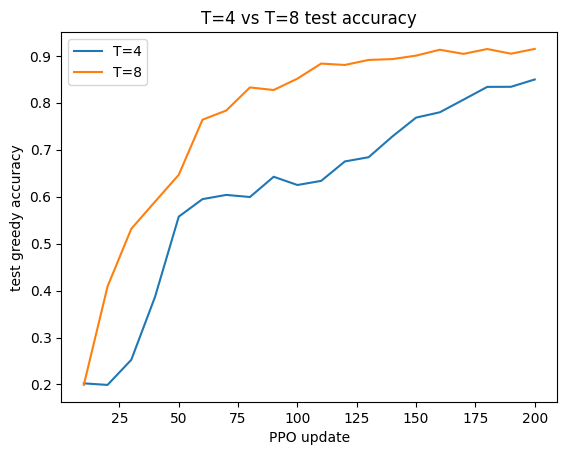

In [ ]:
policy4, x4, a4 = train_policy(T_steps=4, updates=200, seed=0, device=device)
policy8, x8, a8 = train_policy(T_steps=8, updates=200, seed=1, device=device)

plt.figure()
plt.plot(x4, a4, label="T=4")
plt.plot(x8, a8, label="T=8")
plt.xlabel("PPO update")
plt.ylabel("test greedy accuracy")
plt.title("T=4 vs T=8 test accuracy")
plt.legend()
plt.show()

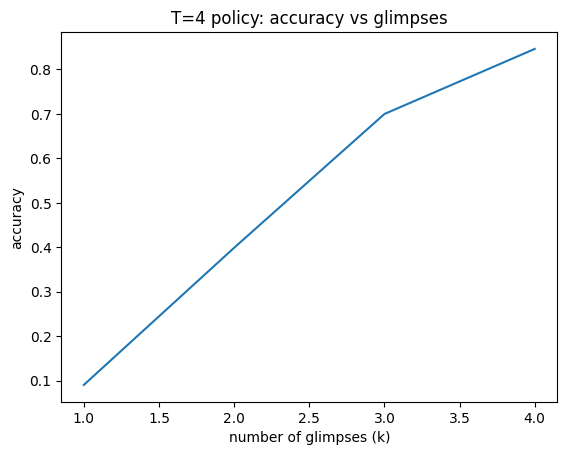

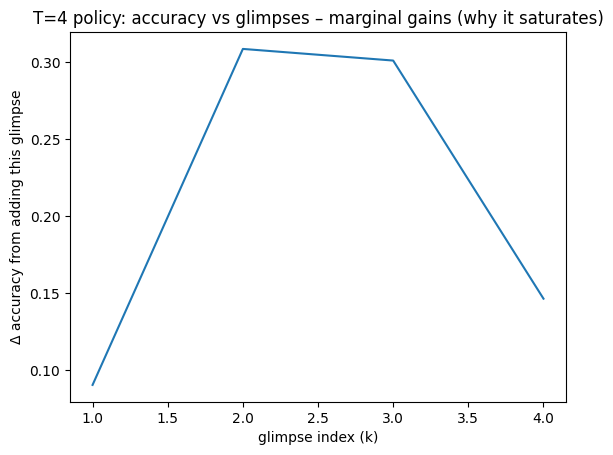

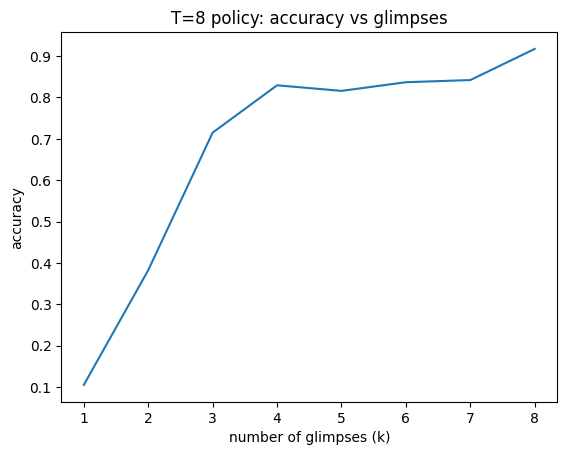

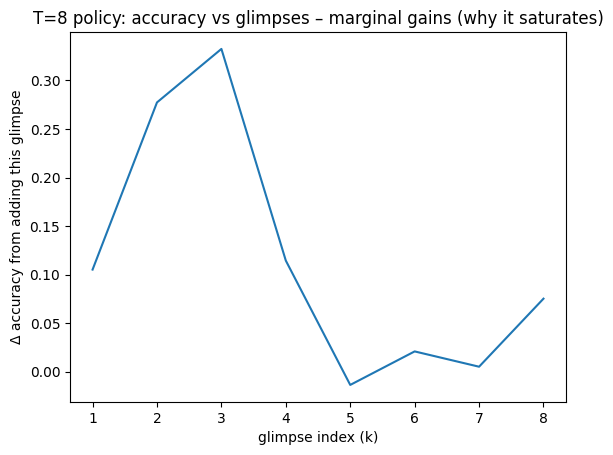

In [ ]:
@torch.no_grad()
def accuracy_vs_glimpses(policy, T_max, patch=7, batch_size=256, n_batches=30, device="cuda"):
    acc = []
    for k in range(1, T_max+1):
        # Evaluate using an env that terminates at k
        env_eval = GlimpseMNISTVecEnv(test_images, test_labels, batch_size=batch_size, patch=patch, T=k, device=device)
        correct = 0
        total = 0
        for _ in range(n_batches):
            obs = env_eval.reset()
            t = torch.zeros(batch_size, dtype=torch.long, device=device)
            r = None
            for step in range(k):
                patch_logits, digit_logits, _ = policy(obs, t)
                patch_a = patch_logits.argmax(dim=-1)
                digit_a = digit_logits.argmax(dim=-1)
                obs, r, done = env_eval.step(patch_a, pred_action=digit_a if step==k-1 else None)
                t = t + 1
            correct += r.sum().item()
            total += r.numel()
        acc.append(correct / total)
    return np.array(acc)

def plot_saturation(acc, title):
    ks = np.arange(1, len(acc)+1)
    plt.figure()
    plt.plot(ks, acc)
    plt.xlabel("number of glimpses (k)")
    plt.ylabel("accuracy")
    plt.title(title)
    plt.show()

    # marginal gain per extra glimpse
    mg = np.diff(np.concatenate([[0.0], acc]))
    plt.figure()
    plt.plot(ks, mg)
    plt.xlabel("glimpse index (k)")
    plt.ylabel("Δ accuracy from adding this glimpse")
    plt.title(title + " – marginal gains (why it saturates)")
    plt.show()

acc4 = accuracy_vs_glimpses(policy4, T_max=4, patch=7, device=device)
plot_saturation(acc4, "T=4 policy: accuracy vs glimpses")

acc8 = accuracy_vs_glimpses(policy8, T_max=8, patch=7, device=device)
plot_saturation(acc8, "T=8 policy: accuracy vs glimpses")

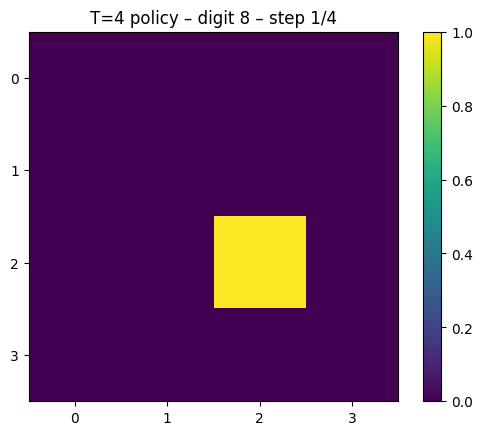

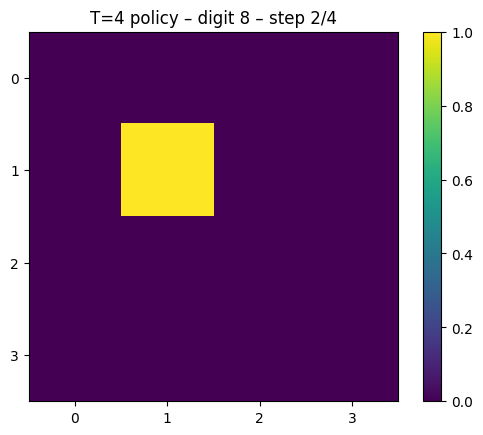

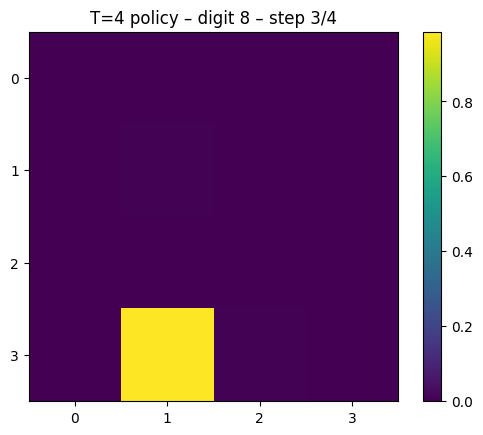

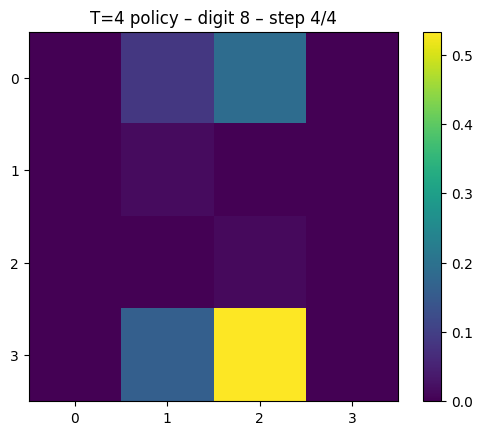

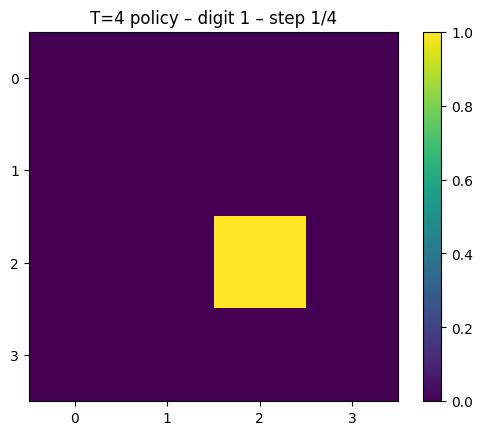

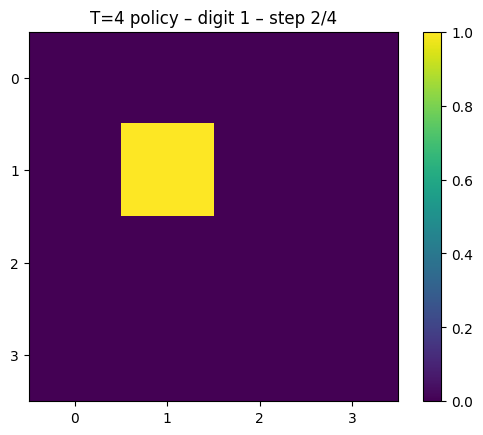

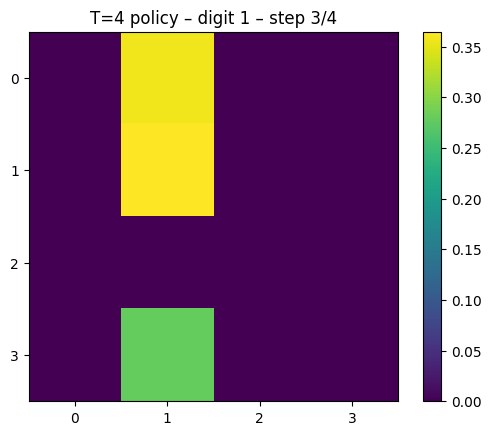

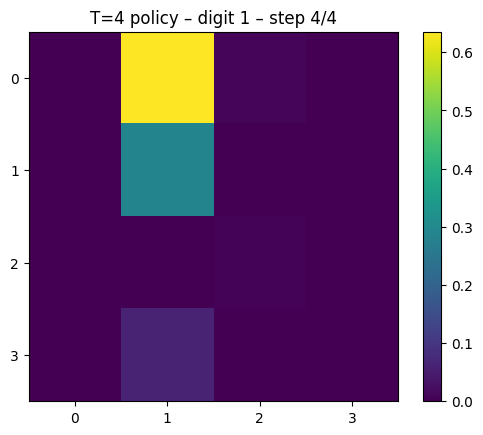

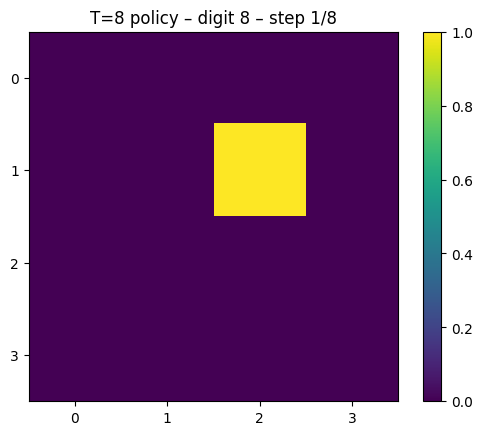

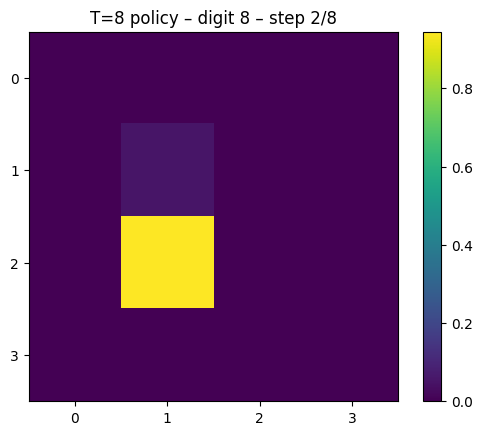

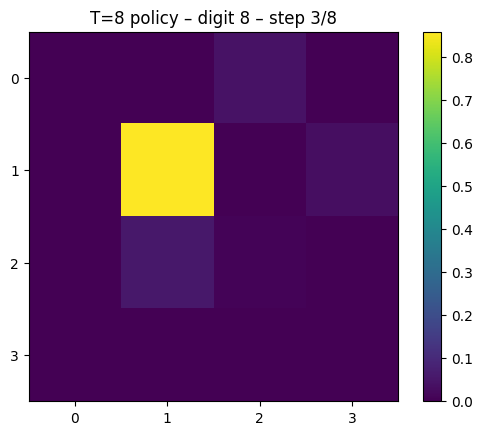

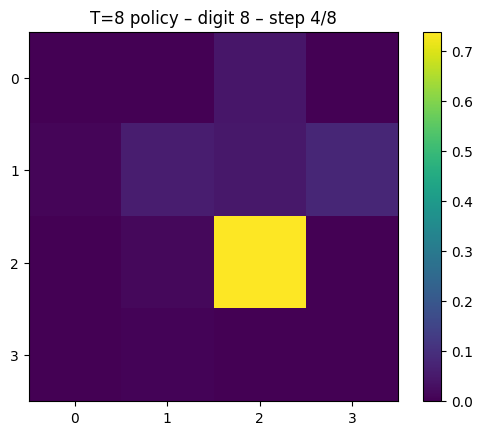

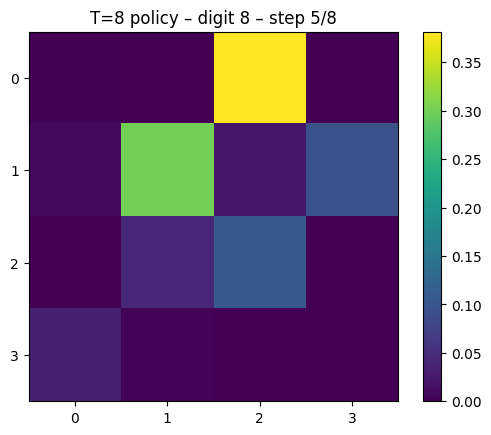

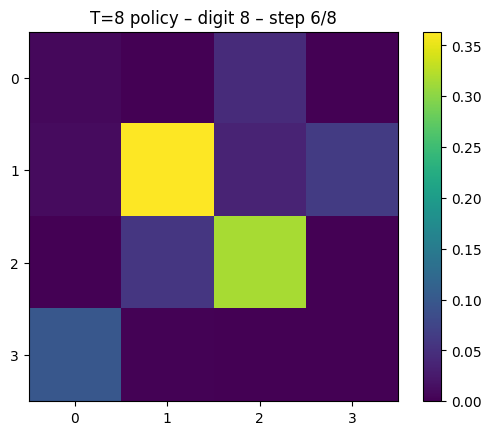

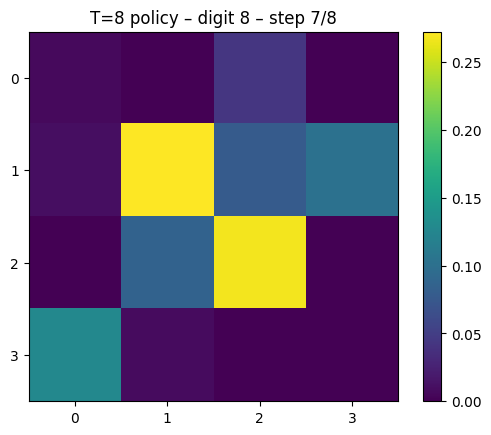

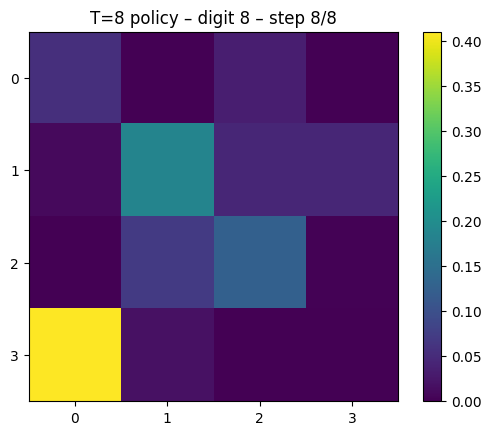

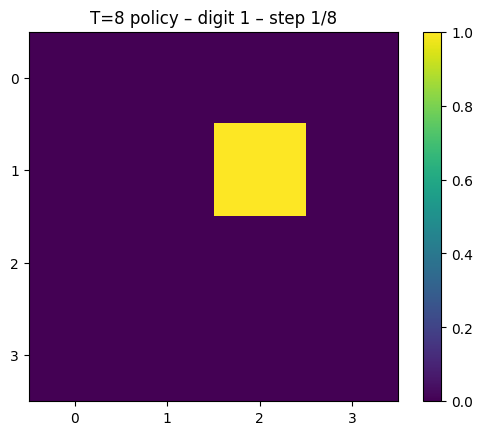

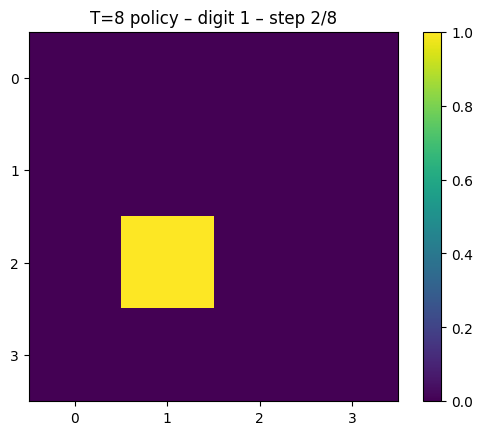

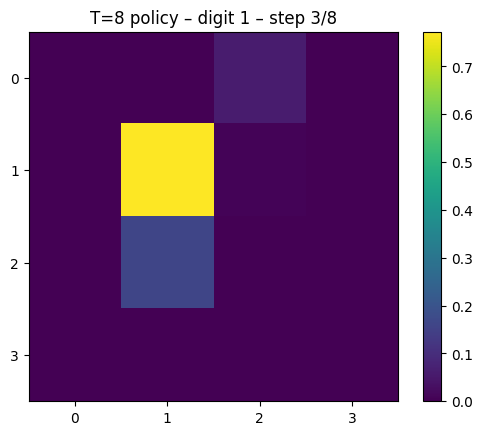

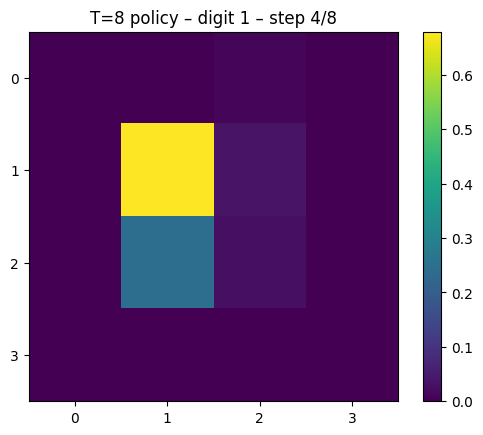

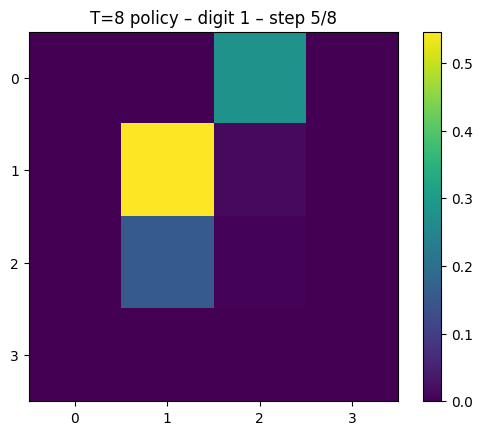

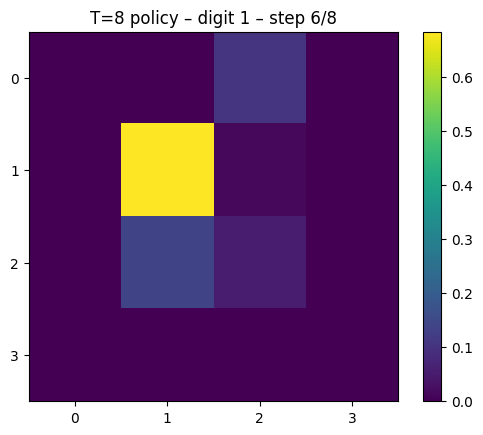

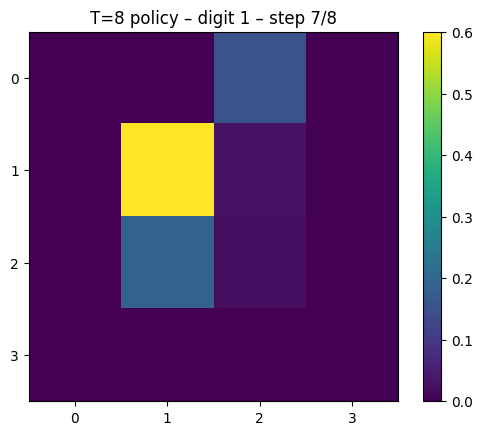

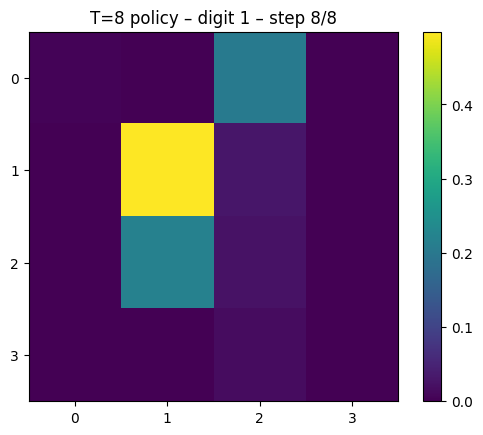

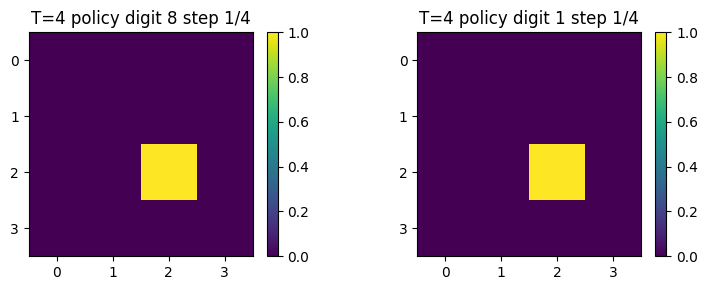

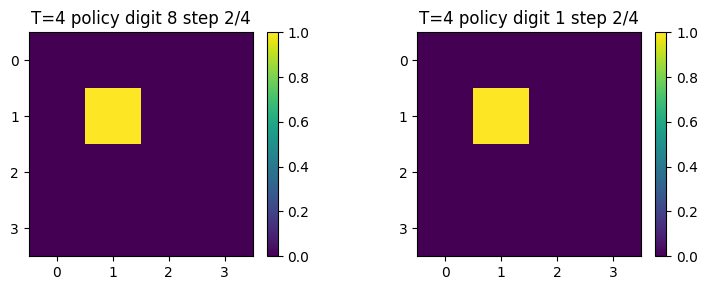

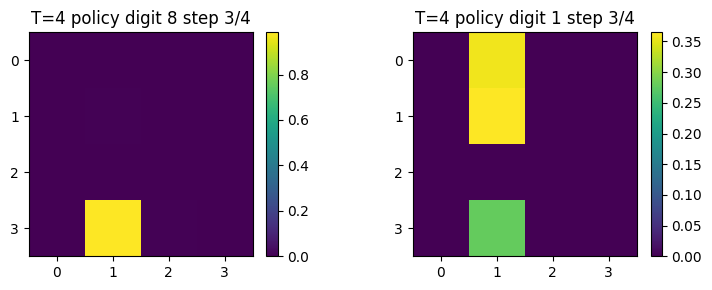

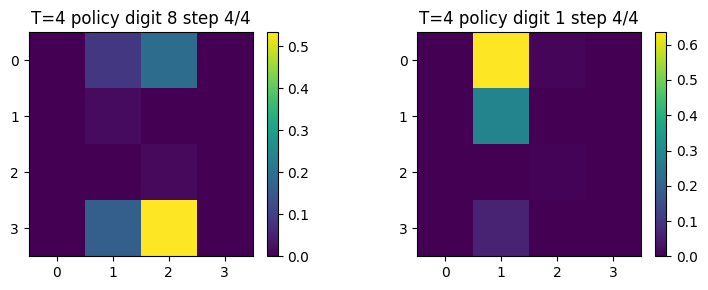

In [ ]:
@torch.no_grad()
def collect_patch_heatmaps_by_digit(policy, T_steps, patch=7, batch_size=512, n_batches=30, device="cuda"):
    env_eval = GlimpseMNISTVecEnv(test_images, test_labels, batch_size=batch_size, patch=patch, T=T_steps, device=device)
    g = env_eval.grid
    counts = torch.zeros((10, T_steps, g, g), dtype=torch.float32)

    for _ in range(n_batches):
        obs = env_eval.reset()
        y = env_eval.y.clone()  # [B] true labels on device
        t = torch.zeros(batch_size, dtype=torch.long, device=device)

        for step in range(T_steps):
            patch_logits, digit_logits, _ = policy(obs, t)
            patch_a = patch_logits.argmax(dim=-1)
            r = patch_a // g
            c = patch_a % g

            for d in range(10):
                m = (y == d)
                if m.any():
                    rd = r[m].tolist()
                    cd = c[m].tolist()
                    for rr, cc in zip(rd, cd):
                        counts[d, step, rr, cc] += 1.0

            digit_a = digit_logits.argmax(dim=-1)
            obs, _, _ = env_eval.step(patch_a, pred_action=digit_a if step==T_steps-1 else None)
            t = t + 1

    probs = counts / counts.sum(dim=(2,3), keepdim=True).clamp_min(1e-9)
    return probs.cpu().numpy(), g

def plot_digit_heatmaps(probs, g, digit, title_prefix):
    # probs: [10,T,g,g]
    T_steps = probs.shape[1]
    for step in range(T_steps):
        plt.figure()
        plt.imshow(probs[digit, step])
        plt.title(f"{title_prefix} – digit {digit} – step {step+1}/{T_steps}")
        plt.xticks(range(g)); plt.yticks(range(g))
        plt.colorbar()
        plt.show()
# 1) Collect per-digit heatmaps
probs_by_digit4, g = collect_patch_heatmaps_by_digit(
    policy4, T_steps=4, patch=7, batch_size=512, n_batches=30, device=device
)

# 2) Plot digit 8 vs digit 1 (all steps)
plot_digit_heatmaps(probs_by_digit4, g, digit=8, title_prefix="T=4 policy")
plot_digit_heatmaps(probs_by_digit4, g, digit=1, title_prefix="T=4 policy")
probs_by_digit8, g = collect_patch_heatmaps_by_digit(
    policy8, T_steps=8, patch=7, batch_size=512, n_batches=30, device=device
)

plot_digit_heatmaps(probs_by_digit8, g, digit=8, title_prefix="T=8 policy")
plot_digit_heatmaps(probs_by_digit8, g, digit=1, title_prefix="T=8 policy")

import matplotlib.pyplot as plt

def plot_two_digits_side_by_side(probs, g, d1, d2, title_prefix):
    """
    probs: [10, T, g, g] (per-digit patch probs per step)
    """
    T_steps = probs.shape[1]
    for step in range(T_steps):
        fig, axes = plt.subplots(1, 2, figsize=(8, 3))

        im1 = axes[0].imshow(probs[d1, step], aspect="equal")
        axes[0].set_title(f"{title_prefix} digit {d1} step {step+1}/{T_steps}")
        axes[0].set_xticks(range(g)); axes[0].set_yticks(range(g))
        fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

        im2 = axes[1].imshow(probs[d2, step], aspect="equal")
        axes[1].set_title(f"{title_prefix} digit {d2} step {step+1}/{T_steps}")
        axes[1].set_xticks(range(g)); axes[1].set_yticks(range(g))
        fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()


#


plot_two_digits_side_by_side(probs_by_digit4, g, d1=8, d2=1, title_prefix="T=4 policy")

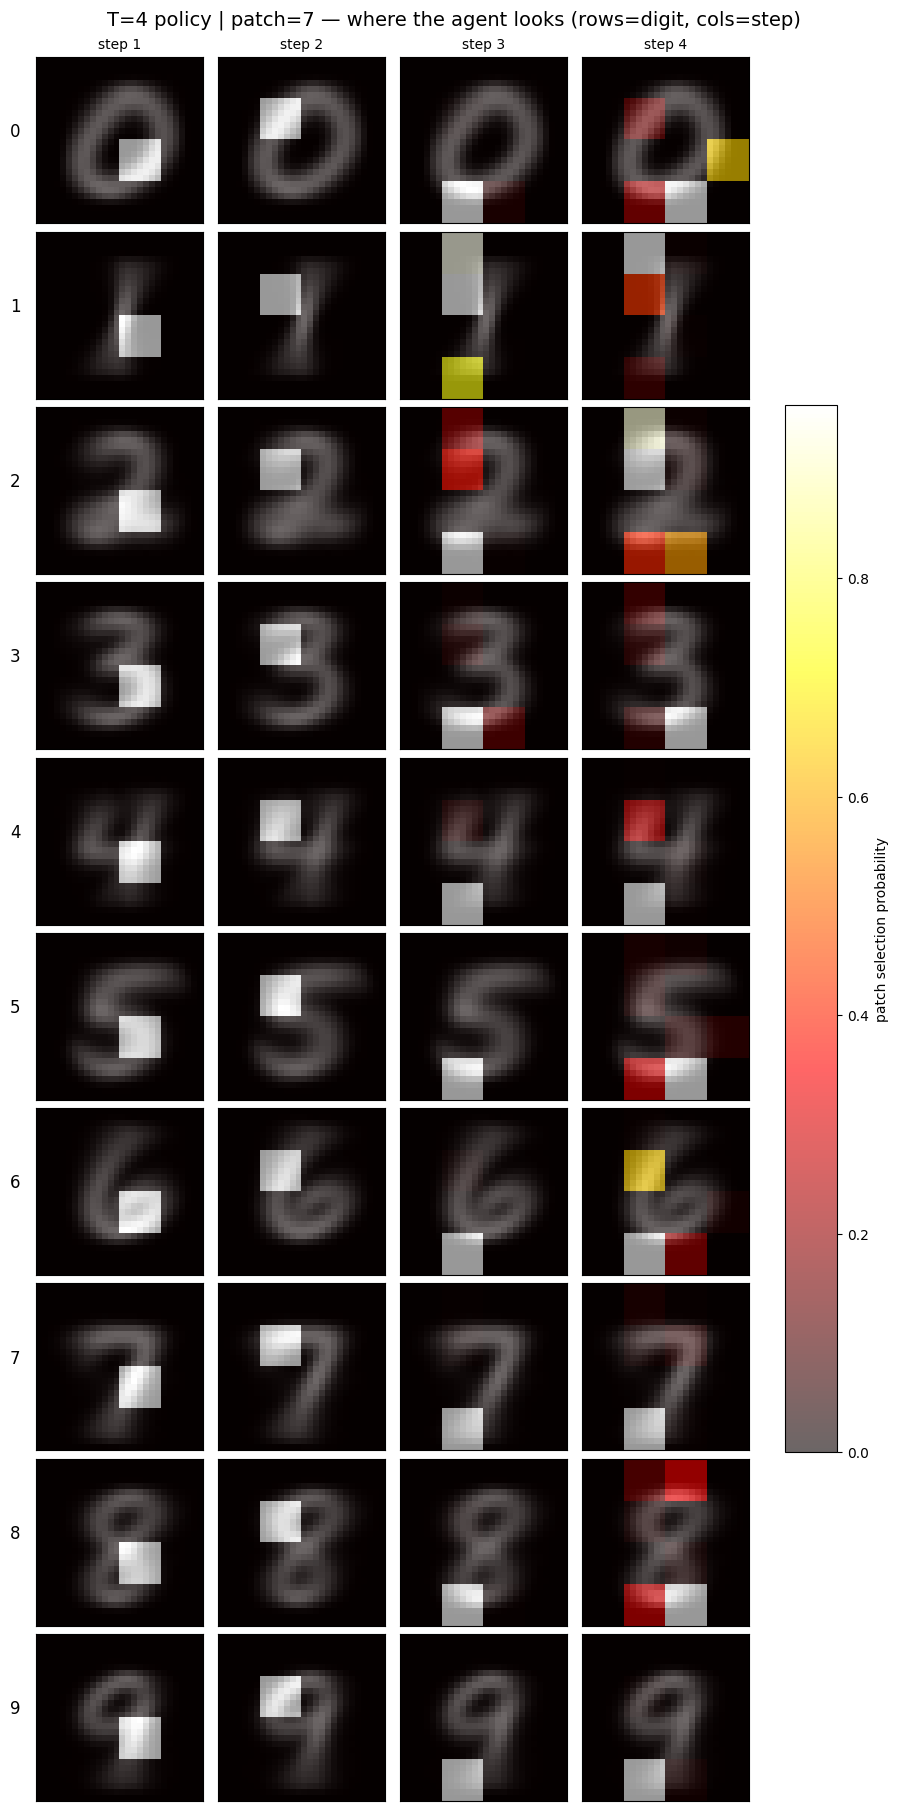

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def patch_heatmap_to_pixels(heatmap, patch):
    """
    heatmap: [grid, grid]
    returns: [28, 28]
    """
    g = heatmap.shape[0]
    p = patch
    pix = np.zeros((28, 28))
    for r in range(g):
        for c in range(g):
            pix[r*p:(r+1)*p, c*p:(c+1)*p] = heatmap[r, c]
    return pix

def plot_all_digits_all_steps(
    probs_by_digit,     # [10, T, grid, grid]
    avg_digits,         # [10, 28, 28]
    patch,
    title_prefix="Policy",
    alpha_heat=0.6,
):
    T_steps = probs_by_digit.shape[1]

    fig, axes = plt.subplots(
        nrows=10,
        ncols=T_steps,
        figsize=(2.2 * T_steps, 18),
        constrained_layout=True,
    )

    for d in range(10):
        for step in range(T_steps):
            ax = axes[d, step] if T_steps > 1 else axes[d]

            # base digit
            ax.imshow(avg_digits[d], cmap="gray")

            # overlay heatmap
            pix_heat = patch_heatmap_to_pixels(
                probs_by_digit[d, step], patch
            )
            im = ax.imshow(pix_heat, cmap="hot", alpha=alpha_heat)

            ax.set_xticks([])
            ax.set_yticks([])

            if d == 0:
                ax.set_title(f"step {step+1}", fontsize=10)
            if step == 0:
                ax.set_ylabel(str(d), fontsize=12, rotation=0, labelpad=15)

    # one shared colorbar
    cbar = fig.colorbar(im, ax=axes, shrink=0.6)
    cbar.set_label("patch selection probability", rotation=90)

    fig.suptitle(
        f"{title_prefix} — where the agent looks (rows=digit, cols=step)",
        fontsize=14,
    )
    plt.show()

import torch

@torch.no_grad()
def compute_avg_digit_images(images, labels):
    """
    images: [N,1,28,28] tensor
    labels: [N] tensor
    returns: avg_digits [10,28,28]
    """
    avg = torch.zeros((10, 28, 28))
    for d in range(10):
        m = (labels == d)
        avg[d] = images[m].mean(dim=0).squeeze(0)
    return avg.numpy()

# compute once (use TEST set to match eval heatmaps)
avg_digits = compute_avg_digit_images(test_images, test_labels)

plot_all_digits_all_steps(
    probs_by_digit4,
    avg_digits,
    patch=7,
    title_prefix="T=4 policy | patch=7",
)